In [274]:
import numpy as np
import matplotlib.pyplot as plt

class Cities:
    def __init__(self, n, seed=None):
        if not (isinstance(n, int) and n > 3):
            raise Exception("n needs to be an integer larger than 3")

        if seed is not None:
            np.random.seed(seed)

        self.n = n

        x = np.random.rand(n)
        y = np.random.rand(n)

        self.x, self.y = x, y

    def __repr__(self) -> str:
        return f"Cities obj with {self.n} cities"




cities = Cities(6, seed=None)
print(cities)
cities.x

Cities obj with 6 cities


array([0.15071754, 0.50819878, 0.69581281, 0.8583588 , 0.32595891,
       0.22024105])

In [275]:
cities.y

array([0.71114953, 0.80950105, 0.34866599, 0.09617655, 0.94052326,
       0.39757202])

In [276]:
another = Cities(5, seed=42)
another.x 

array([0.37454012, 0.95071431, 0.73199394, 0.59865848, 0.15601864])

In [277]:
another.y

array([0.15599452, 0.05808361, 0.86617615, 0.60111501, 0.70807258])

In [278]:
cities.n

6

In [279]:
def init_config(cities: Cities):
    return np.random.permutation(cities.n) # route

route = init_config(cities)

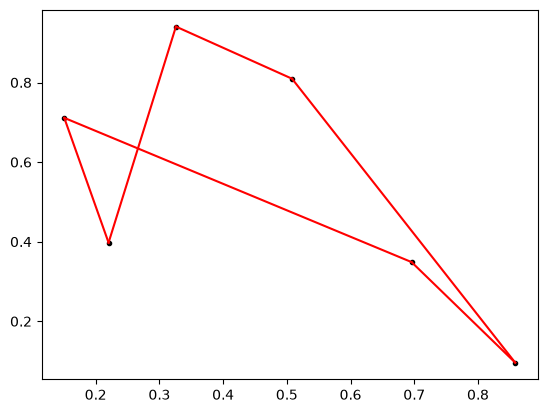

In [280]:
def display(cities, route):
    x, y = cities.x, cities.y

    plt.clf()
    plt.axis("equal")

    plt.plot(x, y, "o", color="black")

    plt.plot(x[route], y[route], color="red")

    comeback = [route[-1], route[0]]

    plt.plot(x[comeback], y[comeback], color="red")

    plt.show()


def display(cities, route):
    x, y, n = cities.x, cities.y, cities.n

    plt.clf()

    plt.plot(x, y, '.', color="black")

    # plt.plot(x[route], y[route], color="red")

    # city0, city1 = route[-1], route[0]

    # plt.plot(
    #     [x[city0], x[city1]],
    #     [y[city0], y[city1]],
    #     color="red"
    # )

    for e in range(n):
        city0 = route[e]
        city1 = route[(e+1)%n]

        plt.plot(
            [x[city0], x[city1]],
            [y[city0], y[city1]],
            color="red"
        )

    plt.pause(0.01)


display(cities, route)

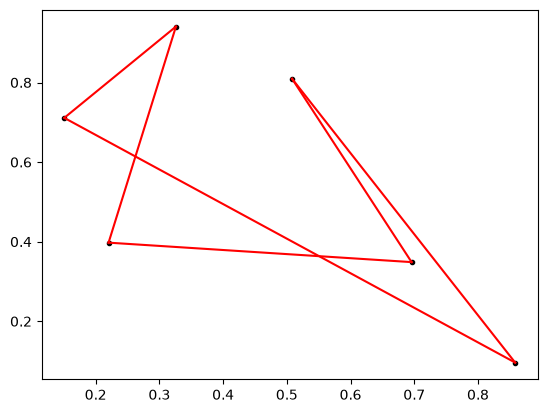

t=1 c=np.float64(3.3783074766661065)
t=2 c=np.float64(2.40729917419687)
final cost c=np.float64(2.40729917419687)


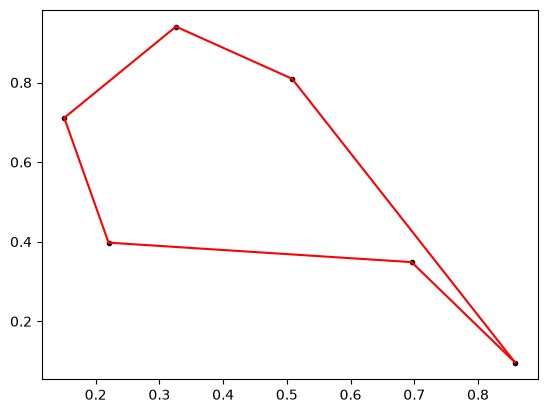

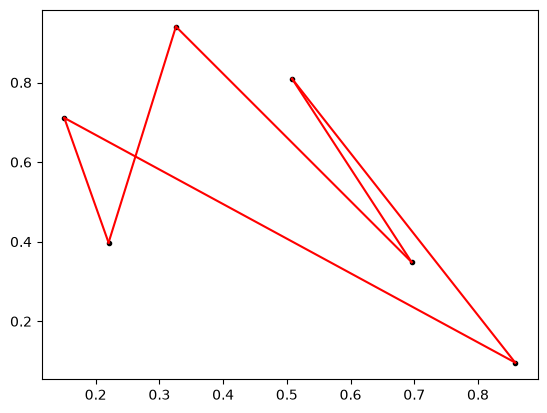

t=0 c=np.float64(3.0379409359843725)
t=2 c=np.float64(2.9052830705720476)
t=6 c=np.float64(2.4072991741968703)
final cost c=np.float64(2.4072991741968703)


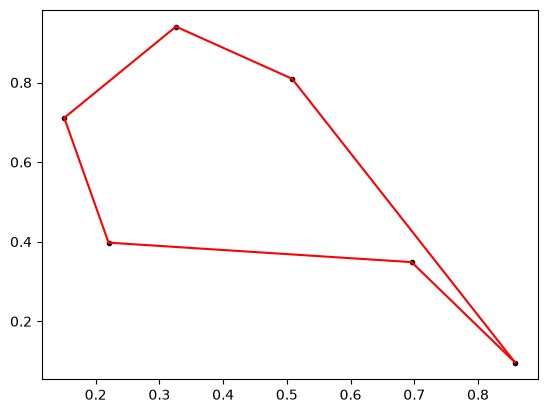

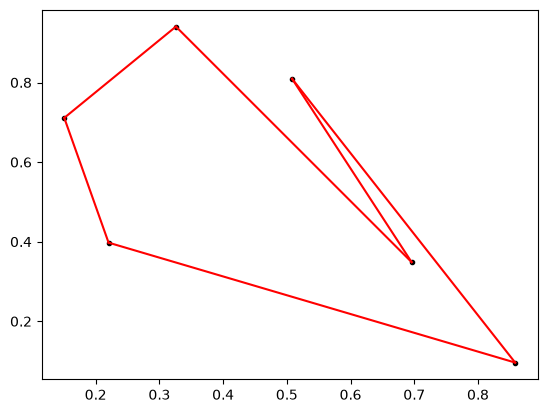

t=0 c=np.float64(2.9052830705720476)
t=1 c=np.float64(2.40729917419687)
final cost c=np.float64(2.40729917419687)


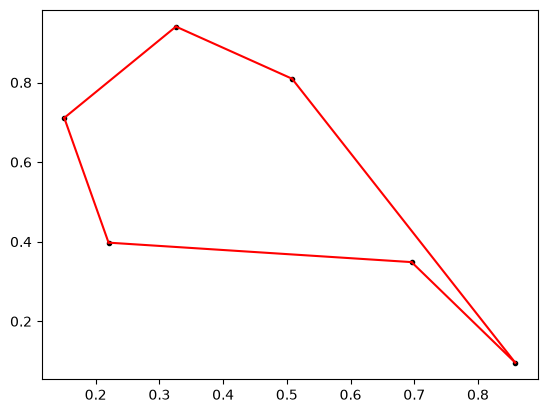

best cost c=2.40729917419687


array([2, 5, 0, 4, 1, 3], dtype=int32)

In [281]:
def dist(cities, city0, city1):
    x, y = cities.x, cities.y

    x0, y0 = x[city0], y[city0]
    x1, y1 = x[city1], y[city1]

    return np.sqrt((x1 - x0)**2 + (y1 - y0)**2)


def cost(cities, route):
    n = cities.n

    c = 0.0

    for e in range(n):
        city0 = route[e]
        city1 = route[(e + 1)%n]

        c += dist(cities, city0, city1)

    return c


def propose_move(route):
    n = len(route)

    while True:

        e1 = np.random.randint(n)
        e2 = np.random.randint(n)

        if e1 > e2:
            e1, e2 = e2, e1

        if e1 != e2 and e1 + 1 != e2 and not (e1 == 0 and e2 == n-1):
            break

    # route[e1+1:e2+1] = route[e1+1:e2+1][::-1]
    new_route = route.copy()
    new_route[e1+1:e2+1] = new_route[e2:e1:-1]
    return new_route


def greedy(cities, max_iters=10, seed=None, restarts=1):
    if seed is not None:
        np.random.seed(seed)

    best_c = np.inf

    best_x = None

    for r in range(restarts):
        x = init_config(cities)
        c = cost(cities, x)

        display(cities, x)

        for t in range(max_iters):
            y = propose_move(x)
            cnew = cost(cities, y)

            if cnew <= c:
                x = y
                c = cnew
                print(f"{t=} {c=}")

        print(f"final cost {c=}")
        display(cities, x)

        if c < best_c:
            best_c = c
            best_x = x

    print(f"best cost c={best_c}")
    # print(x, cost(cities, x))
    # print(best_x, best_c)
    return best_x


greedy(cities, restarts=3)


In [282]:
route = np.arange(6) # 0 -> 1 -> 2 -> 3 -> 4 -> 5 -> 0

e1, e2 = 0, 3 # 2 cạnh được chọn 0->1, 3->4
print(' -> '.join(map(str, route)))

new_route = route.copy()

# new_route[1:4] = new_route[3:0:-1]

""" 
e1, e2 bắt đầu 1 cạnh => e1+1, e2+1

new_route[1:4]    = [1, 2, 3]
new_route[3:0:-1] = [3, 2, 1]

thay [1, 2, 3] thành [3, 2, 1]

0 -> 1 -> <2> -> 3 -> 4 -> <5> : before
0 -> 3 -> <2> -> 1 -> 4 -> <5> : after

Bỏ cạnh:   0 -> 1 và 3 -> 4
Thêm cạnh: 0 -> 3 và 1 -> 4
"""

new_route[e1+1:e2+1] = new_route[e2:e1:-1]
print(' -> '.join(map(str, new_route)))

0 -> 1 -> 2 -> 3 -> 4 -> 5
0 -> 3 -> 2 -> 1 -> 4 -> 5


In [283]:
# e1 >= e2 or e2 = e1 + 1 => slicing trống -> không thay đổi lộ trình
# e1 = 0, e2 = n-1 => đảo chiều toàn vòng, vẫn là cùng tour trong TSP đối xứng

# => chọn 2 cạnh không kề nhau, rồi sắp xếp chỉ số sao cho e1 < e2
print(' -> '.join(map(str, route)))
e1, e2 = 0, 5
new_route = route.copy()
print(new_route[e1+1:e2+1])
print(new_route[e2:e1:-1])
new_route[e1+1:e2+1] = new_route[e2:e1:-1]
print(' -> '.join(map(str, new_route)))

0 -> 1 -> 2 -> 3 -> 4 -> 5
[1 2 3 4 5]
[5 4 3 2 1]
0 -> 5 -> 4 -> 3 -> 2 -> 1
